# FIFA WORLD CUP ANALYSIS

## Objective

The purpose of this notebook is to analyze the FIFA World Cup player statistics

The analysis will:
- Load the cleaned datasets
- Explore the data
- Perform data cleaning if necessary
- Aggregate player statistics by club
- Visualize the findings
- Draw conclusions

In [1]:
# Importing Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
# connecting to the database
conn = sqlite3.connect("../data/raw/worldcup/sqlite_fifa_world_cup_2026.db")

In [3]:
# viewing various dataset
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)


,name
0,teams
1,venues
2,tournament_stages
3,referees
4,matches
5,squads_and_players
6,match_events
7,match_team_stats
8,match_lineups
9,player_stats


In [4]:
# Displaying the schema of the player_stats tabl

pd.read_sql("""PRAGMA table_info(player_stats);""",conn)

,cid,name,type,notnull,dflt_value,pk
0,0,player_id,TEXT,0,None,0
1,1,player_name,TEXT,0,None,0
2,2,team_id,TEXT,0,None,0
3,3,position,TEXT,0,None,0
4,4,matches_played,TEXT,0,None,0
5,5,matches_started,TEXT,0,None,0
6,6,minutes_played,TEXT,0,None,0
7,7,goals,TEXT,0,None,0
8,8,assists,TEXT,0,None,0
9,9,shots,TEXT,0,None,0


In [5]:
#Preview the first 10 rows

pd.read_sql("""
SELECT *
FROM player_stats
LIMIT 10;
""", conn)

,player_id,player_name,team_id,position,matches_played,matches_started,minutes_played,goals,assists,shots,...,yellow_cards,red_cards,penalty_goals,own_goals,clean_sheets,saves,goals_conceded,average_rating,data_source,last_verified
0,1,José Raúl Rangel,1,GK,5,5,438,0,0,,...,0,0,0,0,4,7,3,,sofascore.com,2026-07-09
1,2,Jorge Eduardo Sanchez,1,DEF,4,4,349,0,1,,...,1,0,0,0,,,,,sofascore.com,2026-07-09
2,3,César Jasib Montes,1,DEF,4,4,315,0,0,,...,0,1,0,0,,,,,sofascore.com,2026-07-09
3,4,Edson Omar Alvarez,1,DEF,4,2,239,0,0,,...,1,0,0,0,,,,,sofascore.com,2026-07-09
4,5,Johan Felipe Vasquez,1,DEF,4,4,360,0,0,,...,1,0,0,0,,,,,sofascore.com,2026-07-09
5,6,Erik Antonio Lira,1,MID,4,4,346,0,1,,...,0,0,0,0,,,,,sofascore.com,2026-07-09
6,7,Luis Francisco Romo,1,MID,4,4,268,1,1,,...,0,0,0,0,,,,,sofascore.com,2026-07-09
7,8,Álvaro Fidalgo,1,MID,3,1,95,1,0,,...,0,0,0,0,,,,,sofascore.com,2026-07-09
8,9,Raúl Alonso Jimenez,1,FWD,4,4,319,3,0,,...,0,0,1,0,,,,,sofascore.com,2026-07-09
9,10,Ernesto Alexis Vega,1,FWD,1,0,11,0,0,,...,0,0,0,0,,,,,sofascore.com,2026-07-09


In [6]:
# top 5 scorers of the tournament at the moment and their total contributions

pd.read_sql("""
SELECT 
    player_name,
    goals,
    assists,
    (goals + assists) AS goal_contributions
FROM player_stats
ORDER BY goal_contributions DESC
LIMIT 10;
""", conn)

,player_name,goals,assists,goal_contributions
0,Kylian Mbappe,8,3,11
1,Lionel Andrés Messi,8,1,9
2,Erling Braut Haaland,7,0,7
3,Harry Edward Kane,6,1,7
4,Masour Ousmane Dembele,5,1,6
5,Michael Akpovie Olise,0,6,6
6,Julián Andrés Quinones,4,1,5
7,Johan Kula Manzambi,3,2,5
8,José Vinicius,4,1,5
9,Deniz Undav,3,2,5


In [7]:
# Displaying the schema of the squads_and_players

pd.read_sql("""PRAGMA table_info(squads_and_players);""",conn)

,cid,name,type,notnull,dflt_value,pk
0,0,player_id,TEXT,0,None,0
1,1,team_id,TEXT,0,None,0
2,2,player_name,TEXT,0,None,0
3,3,position,TEXT,0,None,0
4,4,club_team,TEXT,0,None,0
5,5,market_value_eur,TEXT,0,None,0
6,6,caps,TEXT,0,None,0
7,7,date_of_birth,TEXT,0,None,0
8,8,height_cm,TEXT,0,None,0
9,9,goals,TEXT,0,None,0


In [8]:
# Preview the first 10 rows
pd.read_sql("""
SELECT *
FROM squads_and_players
LIMIT 10;
""", conn)

,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals
0,1,1,José Raúl Rangel,GK,CD Guadalajara,8933646,15,2000-02-25,190,0
1,2,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,24628639,59,1997-12-10,176,3
2,3,1,César Jasib Montes,DEF,FC Lokomotiv Moscow,10912552,69,1997-02-24,191,4
3,4,1,Edson Omar Alvarez,DEF,Fenerbahçe SK,10875943,100,1997-10-24,180,7
4,5,1,Johan Felipe Vasquez,DEF,Genoa CFC,18265363,47,1998-10-22,182,3
5,6,1,Erik Antonio Lira,MID,CF Cruz Azul,21520963,26,2000-05-08,172,0
6,7,1,Luis Francisco Romo,MID,CD Guadalajara,12552748,62,1995-06-05,183,4
7,8,1,Álvaro Fidalgo,MID,Real Betis,10697494,5,1997-04-09,175,0
8,9,1,Raúl Alonso Jimenez,FWD,Fulham FC,15211168,127,1991-05-05,188,46
9,10,1,Ernesto Alexis Vega,FWD,Deportivo Toluca FC,17281661,53,1997-11-25,175,7


In [9]:
#finding the attacking prowess of the players by clubs
query = """
SELECT
    s.club_team,
    SUM(p.goals) AS total_goals,
    SUM(p.assists) AS total_assists,
    SUM(p.goals) + SUM(p.assists) AS total_contributions
FROM player_stats AS p
JOIN squads_and_players AS s
    ON p.player_id = s.player_id
GROUP BY s.club_team
ORDER BY total_contributions DESC
LIMIT 10;
"""

club_analysis = pd.read_sql(query, conn)

club_analysis

,club_team,total_goals,total_assists,total_contributions
0,Real Madrid C. F.,17,12,29
1,FC Bayern München,8,13,21
2,Paris Saint-Germain,13,6,19
3,Liverpool FC,6,13,19
4,Arsenal FC,8,10,18
5,Newcastle United FC,5,6,11
6,Sunderland AFC,8,2,10
7,Inter Miami CF,8,2,10
8,Crystal Palace FC,8,1,9
9,Manchester United FC,7,1,8


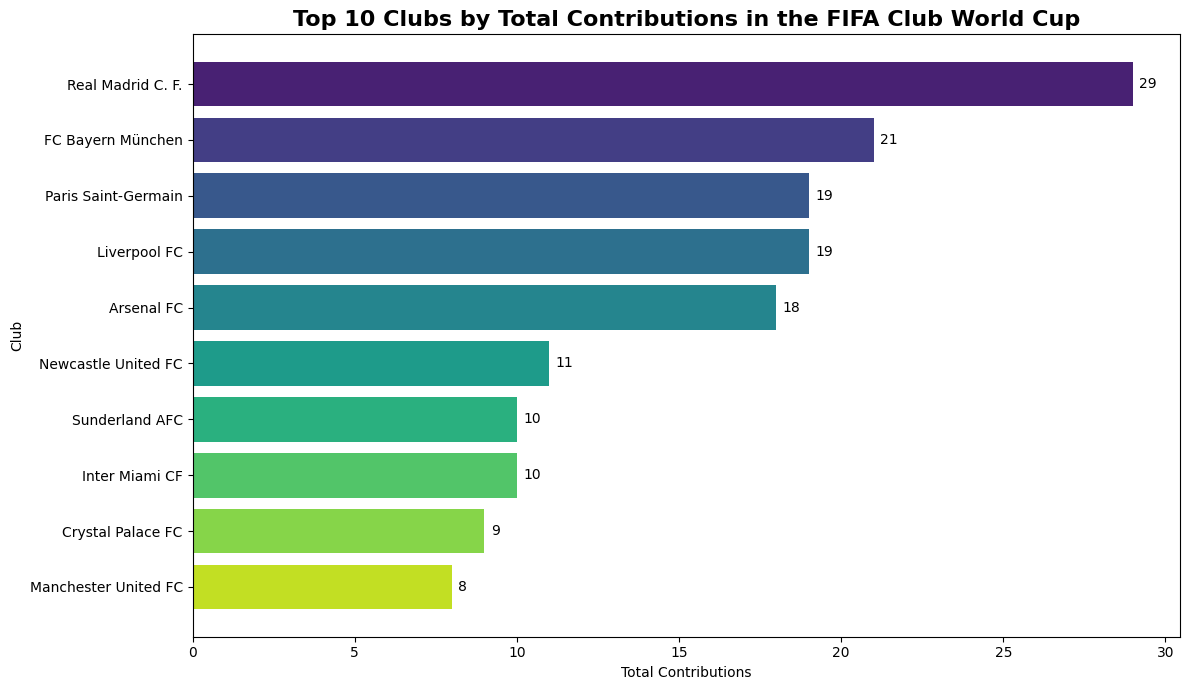

In [10]:
# visualizing the top 10 clubs by total contributions in the FIFA Club World Cup
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    club_analysis["club_team"],
    club_analysis["total_contributions"],
    color=sns.color_palette("viridis", n_colors=len(club_analysis))
)

ax.set_title(
    "Top 10 Clubs by Total Contributions in the FIFA Club World Cup",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Total Contributions")
ax.set_ylabel("Club")

ax.invert_yaxis()

# Display values on the bars
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

#Key Findings
- Real Madrid C.F. lead the clubs by total contributions.
- Paris Saint-Germain and Bayern Munich are also among the strongest contributors
- Big clubs like Barcelona and Chelsea are missing out

